# **Universidad de Buenos Aires**
# CEIA - Aprendizaje por Refuerzo I
# Tema: Monte Carlo Off-Policy con Importance Sampling (MCIS) en FrozenLake
---
# Trabajo Práctico 1

De acuerdo a la siguiente celda:
1. Resolver y responder las preguntas modificando el código original y reescribiéndolo luego de cada pregunta.
2. **Ejecutar 3 veces** cada celda modificada antes de responder cada pregunta.

Ep 5000 | ε=0.082 | Reward medio (últ. 1k): 0.061
Ep 10000 | ε=0.010 | Reward medio (últ. 1k): 0.086
Ep 15000 | ε=0.010 | Reward medio (últ. 1k): 0.078
Ep 20000 | ε=0.010 | Reward medio (últ. 1k): 0.092


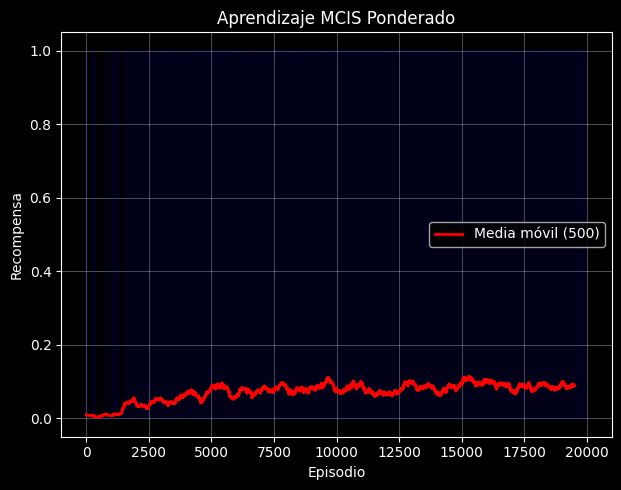


✅ Tasa de éxito de la política aprendida: 8.8%

Política aprendida (← 0, ↓ 1, → 2, ↑ 3):
🤖 ↑ ← ← 
↓ 🕳️ ← 🕳️ 
↑ → ← 🕳️ 
🕳️ ↑ ↓ 🎯 


In [33]:
# ============================================================
# 1: Instalación e imports
# ============================================================
!pip install gymnasium matplotlib numpy -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from collections import defaultdict

np.random.seed(42)

# ============================================================
# 2: Entorno y parámetros
# ============================================================
env = gym.make('FrozenLake-v1', is_slippery=True, map_name="4x4")

NUM_EPISODES = 20000
GAMMA = 1.0
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.9995

# ============================================================
# 3: Inicialización
# ============================================================

Q = defaultdict(lambda: np.zeros(env.action_space.n))
C = defaultdict(lambda: np.zeros(env.action_space.n))

def greedy_policy(s):
    return int(np.argmax(Q[s]))

def pi_prob(s, a):
    """π(a|s): 1 si es la acción greedy, 0 si no."""
    return 1.0 if a == greedy_policy(s) else 0.0

def mu_prob(s, a, epsilon):
    """Política de comportamiento (ε-greedy)"""
    nA = env.action_space.n
    if a == greedy_policy(s):
        return 1.0 - epsilon + epsilon / nA
    else:
        return epsilon / nA


# ============================================================
# 4: Generación de episodio
# ============================================================
def generate_episode(epsilon):
    episode = []
    state, _ = env.reset()
    while True:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = greedy_policy(state)

        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))

        if terminated or truncated:
            break
        state = next_state
    return episode

# ============================================================
# 5: Bucle principal MCIS
# ============================================================
rewards_per_episode = []
epsilon = EPSILON_START

for ep in range(NUM_EPISODES):
    episode = generate_episode(epsilon)

    G = 0.0
    W = 1.0

    # Bucle hacia atrás
    for t in range(len(episode) - 1, -1, -1):
        St, At, Rt = episode[t]
        G = GAMMA * G + Rt

        C[St][At] += W
        Q[St][At] += (W / C[St][At]) * (G - Q[St][At])
        W = W * (pi_prob(St, At) / mu_prob(St, At, epsilon))

        if W == 0:
            break

    rewards_per_episode.append(episode[-1][2])
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    if (ep + 1) % 5000 == 0:
        avg_last = np.mean(rewards_per_episode[-1000:])
        print(f"Ep {ep+1} | ε={epsilon:.3f} | Reward medio (últ. 1k): {avg_last:.3f}")

# ============================================================
# 6: Visualización
# ============================================================
def moving_average(x, w=500):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode, alpha=0.1, color='blue')
plt.plot(moving_average(rewards_per_episode, 500), color='red', linewidth=2, label='Media móvil (500)')
plt.xlabel('Episodio'); plt.ylabel('Recompensa')
plt.title('Aprendizaje MCIS Ponderado')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 7: Evaluación y Política Final
# ============================================================
def evaluate_policy(n_eval=1000):
    successes = 0
    for _ in range(n_eval):
        state, _ = env.reset()
        done = False
        while not done:
            action = greedy_policy(state) # Evaluación 100% Greedy
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            if terminated and reward == 1.0:
                successes += 1
                break
    return successes / n_eval

print(f"\n✅ Tasa de éxito de la política aprendida: {evaluate_policy()*100:.1f}%")

ARROWS = {0: '←', 1: '↓', 2: '→', 3: '↑'}
SPECIAL = {0: '🤖', 5: '🕳️', 7: '🕳️', 11: '🕳️', 12: '🕳️', 15: '🎯'}

print("\nPolítica aprendida (← 0, ↓ 1, → 2, ↑ 3):")
for row in range(4):
    line = ""
    for col in range(4):
        s = row * 4 + col
        if s in SPECIAL:
            line += SPECIAL[s] + " "
        else:
            line += ARROWS[greedy_policy(s)] + " "
    print(line)

**1.** ¿Qué ocurre si se inicializa `Q` en un valor diferente a 0? ¿Por qué? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [34]:
# Pregunta 1: modifique acá el código original para inicializar Q en un valor
# distinto de 0 y analice el resultado


Respuesta

**2.** ¿Qué ocurre si se cambia la política de exploración de π (que actualmente es una política *hard*, greedy) a una política ε-greedy (reemplazar `def pi_prob` por una función `def pi_prob_soft` que sea ε-greedy, y a su vez cambiar `if W == 0.0: break` por `if W < 1e-5: break`)? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [35]:
# Pregunta 2: modifique acá el código original agregando pi_prob_soft
# (epsilon-greedy) y la nueva condición de corte del bucle


Respuesta

**3.** ¿Qué ocurre si se reduce el valor de `EPSILON_START`? ¿Qué valor de `EPSILON_START` es más conveniente? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [36]:
# Pregunta 3: modifique acá el código original probando distintos valores de
# EPSILON_START


Respuesta

**4.** ¿Qué sucede si se reduce el valor de `GAMMA`? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [37]:
# Pregunta 4: modifique acá el código original probando distintos valores de
# GAMMA


Respuesta

**5.** ¿Qué ocurre si se aumenta la cantidad de episodios? (VALOR EJERCICIO 0.4)

In [38]:
# Pregunta 5: modifique acá el código original aumentando la cantidad de
# episodios (NUM_EPISODES)


Respuesta

**6.** ¿Qué ocurre si se reduce la tasa de decaimiento de ε (`EPSILON_DECAY`) para prolongar la fase de exploración? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [39]:
# Pregunta 6: modifique acá el código original reduciendo la tasa de decaimiento
# de epsilon (EPSILON_DECAY)


Respuesta

**7.** ¿Qué valor conviene darle a la tasa de decaimiento si se aumenta la cantidad de episodios a:

- 60000
- 100000
- 300000
- 500000
- 700000

¿Mejora, empeora o se mantiene aproximadamente igual la tasa de éxito? (VALOR EJERCICIO 0.9)

In [40]:
# Pregunta 7: modifique acá el código original probando distintas combinaciones
# de NUM_EPISODES y EPSILON_DECAY


Respuesta